# Eksperyment: Wpływ funkcji straty na wyniki MLP

W tym notatniku zbadamy wpływ funkcji straty na proces uczenia modelu MLP.

Dla zadania klasyfikacji porównamy dwie funkcje straty: entropię krzyżową (cross-entropy) oraz błąd średniokwadratowy (MSE). Dla zadania regresji porównujemy MSE oraz MAE (Mean Absolute Error).

In [ ]:
# from mlp.mlp import MLP
# from mlp.utils import plot_accuracy
# import inspect
#
# # print(inspect.getsource(plot_accuracy))
# print(inspect.getsource(MLP.__init__))

In [ ]:
import numpy as np
from mlp.mlp import MLP
from mlp.utils import (
    load_dataset, plot_dataset, plot_loss, accuracy,
    plot_decision_boundary, plot_accuracy, plot_weights_together
)

In [ ]:
# === 1. Konfiguracja ===

# Wybierz zadanie i plik danych:
# przykład: "lab1_data/Classification/data.simple.train.1000.csv"
data_path = "../lab1_data/Classification/data.simple.train.100.csv"
task = "binary"          # "binary", "multiclass", "regression"
activation = "gelu"      # "sigmoid", "gelu", "identity"
losses = ["mse", "binary_cross_entropy"]  # zależnie od zadania
epochs = 1000
learning_rate = 0.01

In [ ]:
X, y = load_dataset(data_path)
plot_dataset(X, y, title=f"Training data ({data_path.split('/')[-1]})")

FileNotFoundError: [Errno 2] No such file or directory: '../lab1_data/Classification/data.cube.train.500.csv'

In [ ]:
# === 3. Eksperyment z różnymi funkcjami strat ===
results = {}

for loss in losses:
    print(f"\n=== Training with loss: {loss} ===")
    model = MLP(
        layer_sizes=[X.shape[1], 16, (1 if task != "multiclass" else len(np.unique(y)))],
        task=task,
        activation=activation,
        learning_rate=learning_rate,
        loss=loss,
        seed=42
    )

    history, weight_history, acc_history = model.fit(X, y, epochs=epochs, verbose=True)
    results[loss] = {
        "model": model,
        "loss_history": history,
        "weight_history": weight_history,
        "acc_history": acc_history
    }

    # --- Wizualizacje ---
    plot_loss(history, title=f"Loss evolution ({loss})")

    # tylko dla klasyfikacji (binary / multiclass)
    if task in ["binary", "multiclass"]:
        preds = model.predict(X)
        acc_final = accuracy(y, preds)

        print("\n=== Porównanie predykcji vs prawdziwe etykiety ===")
        for i, (p, t) in enumerate(zip(preds.ravel(), y.ravel())):
            print(f"{i:3d}: pred = {int(p)}, true = {int(t)}, equal = {p == t}")

        print(f"Final accuracy ({loss}): {acc_final:.4f}")

        # wykres dokładności w czasie
        plot_accuracy(acc_history, title=f"Accuracy evolution ({loss})")

    # wykres zmian wag
    plot_weights_together(weight_history, title=f"Weight evolution ({loss})")

    # granica decyzyjna (tylko klasyfikacja)
    if task != "regression":
        plot_decision_boundary(model, X, y, title=f"Decision boundary ({loss})")


=== Training with loss: mse ===


NameError: name 'X' is not defined

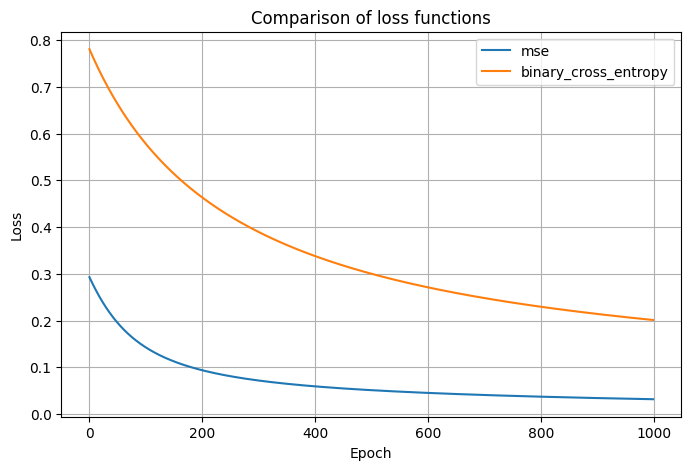

In [ ]:
# === 4. Porównanie funkcji straty ===
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for loss, res in results.items():
    plt.plot(res["loss_history"], label=loss)
plt.title("Comparison of loss functions")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()